# ml_sandbox_27 — Random Forest (Dedicated)

Dedicated tuning for Random Forest following the nb21 pipeline exactly, with one extension: **100 Optuna trials** instead of nb21's 30, same search space and pipeline steps.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, log_loss,
    RocCurveDisplay, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.calibration import calibration_curve

In [2]:
RANDOM_STATE = 42
N_SPLITS     = 5
N_TRIALS     = 100
LAM          = 0.3
MIN_N        = 5

CENTRALITY_COLS = [
    'betweenness_centrality_top20_rolling5',
    'harmonic_closeness_centrality_top20_rolling5',
    'eigenvector_centrality_top20_rolling5',
]
SHORT = {c: c.replace('_centrality_top20_rolling5', '') for c in CENTRALITY_COLS}

df = pd.read_csv('df_artists_final.csv', index_col=0).reset_index()
X  = df.drop(columns=['top_20_hitmaker'])
y  = df['top_20_hitmaker']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

imp      = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imp.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(imp.transform(X_test),      columns=X_test.columns,  index=X_test.index)

print(f'Train: {X_train_imp.shape}  Test: {X_test_imp.shape}')
print(f'Class balance (train): {y_train.mean():.3f} hitmaker')

Train: (607, 26)  Test: (152, 26)
Class balance (train): 0.432 hitmaker


## Helper functions

In [3]:
def build_rf(params):
    return RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params.get('max_depth'),
        min_samples_leaf=params.get('min_samples_leaf', 1),
        max_features=params.get('max_features', 'sqrt'),
        max_leaf_nodes=params.get('max_leaf_nodes'),
        class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1,
    )


def cv_evaluate(X, y, params, skf):
    fold_val, fold_tr = [], []
    for tr_idx, val_idx in skf.split(X, y):
        X_f, X_v = X.iloc[tr_idx], X.iloc[val_idx]
        y_f, y_v = y.iloc[tr_idx], y.iloc[val_idx]
        m = build_rf(params)
        m.fit(X_f, y_f)
        fold_val.append(roc_auc_score(y_v, m.predict_proba(X_v)[:, 1]))
        fold_tr.append(roc_auc_score(y_f,  m.predict_proba(X_f)[:, 1]))
    cv_auc = np.mean(fold_val)
    gap    = np.mean(fold_tr) - cv_auc
    return {'CV AUC': cv_auc, 'CV Std': np.std(fold_val),
            'Train AUC': np.mean(fold_tr), 'Overfit Gap': gap,
            'Penalized': cv_auc - LAM * gap}


def make_objective(X, y):
    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
            'max_depth':        trial.suggest_int('max_depth', 2, 15),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
            'max_features':     trial.suggest_categorical('max_features',
                                    ['sqrt', 'log2', 0.3, 0.5, 0.7]),
        }
        fold_val, fold_tr = [], []
        for tr_idx, val_idx in skf.split(X, y):
            X_f, X_v = X.iloc[tr_idx], X.iloc[val_idx]
            y_f, y_v = y.iloc[tr_idx], y.iloc[val_idx]
            m = build_rf(params)
            m.fit(X_f, y_f)
            fold_val.append(roc_auc_score(y_v, m.predict_proba(X_v)[:, 1]))
            fold_tr.append(roc_auc_score(y_f,  m.predict_proba(X_f)[:, 1]))
        val_auc = np.mean(fold_val)
        return val_auc - LAM * (np.mean(fold_tr) - val_auc)
    return objective


def compute_shap_importance(model, X_val):
    try:
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(X_val)
        if isinstance(sv, list): sv = sv[1]
        elif sv.ndim == 3:       sv = sv[:, :, 1]
        return pd.DataFrame({'Feature': X_val.columns,
                             'Importance': np.abs(sv).mean(axis=0)})\
                 .sort_values('Importance', ascending=False).reset_index(drop=True)
    except Exception:
        perm = permutation_importance(model, X_val, n_repeats=10,
                   random_state=RANDOM_STATE, scoring='roc_auc')
        return pd.DataFrame({'Feature': X_val.columns,
                             'Importance': perm.importances_mean})\
                 .sort_values('Importance', ascending=False).reset_index(drop=True)

## Step 1 — Optuna (100 trials)

Standard search space, identical to nb21 but with 100 trials instead of 30.
Best params selected by penalized CV AUC: `CV AUC − λ × Overfit Gap`.

In [4]:
print(f'Optuna ({N_TRIALS} trials)...')
study = optuna.create_study(direction='maximize',
                            sampler=TPESampler(seed=RANDOM_STATE))
study.optimize(make_objective(X_train_imp, y_train),
               n_trials=N_TRIALS, show_progress_bar=True)

params_full = study.best_params
res_full    = cv_evaluate(X_train_imp, y_train, params_full, skf)

print(f'  CV AUC:    {res_full["CV AUC"]:.4f} ± {res_full["CV Std"]:.4f}')
print(f'  Train AUC: {res_full["Train AUC"]:.4f}')
print(f'  Gap:       {res_full["Overfit Gap"]:.4f}')
print(f'  Penalized: {res_full["Penalized"]:.4f}')
print(f'  Params:    {params_full}')

Optuna (100 trials)...


  0%|          | 0/100 [00:00<?, ?it/s]

  CV AUC:    0.7518 ± 0.0329
  Train AUC: 0.7810
  Gap:       0.0293
  Penalized: 0.7430
  Params:    {'n_estimators': 160, 'max_depth': 2, 'min_samples_leaf': 17, 'max_features': 0.7}


## Step 2 — CV SHAP Importance + Genre Consolidation

SHAP computed on held-out folds with the winner params. Low-signal genre dummies are folded into `artist_genre_other`.

In [5]:
# CV SHAP importance
fold_imps = []
for tr_idx, val_idx in skf.split(X_train_imp, y_train):
    X_f, X_v = X_train_imp.iloc[tr_idx], X_train_imp.iloc[val_idx]
    y_f, y_v = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    m = build_rf(params_full)
    m.fit(X_f, y_f)
    perm_df = compute_shap_importance(m, X_v)
    fold_imps.append(perm_df.set_index('Feature')['Importance'])

perm_df_full = (pd.concat(fold_imps, axis=1)
                  .mean(axis=1)
                  .sort_values(ascending=False)
                  .reset_index())
perm_df_full.columns = ['Feature', 'Importance']
print('Top 15 features by CV SHAP:')
print(perm_df_full.head(15).to_string(index=False))

# Genre consolidation
all_genre_cols = [c for c in X_train_imp.columns if c.startswith('artist_genre_')]
genre_imp      = perm_df_full.set_index('Feature')['Importance']
genre_vals     = genre_imp[[c for c in all_genre_cols if c in genre_imp.index]]
high_genres    = [c for c in all_genre_cols if genre_imp.get(c, 0) > genre_vals.mean()]
low_genres     = [c for c in all_genre_cols if c not in high_genres]

X_tr_c = X_train_imp.drop(columns=low_genres).copy()
X_te_c = X_test_imp.drop(columns=low_genres).copy()
if low_genres:
    X_tr_c['artist_genre_other'] = (X_train_imp[low_genres].sum(axis=1) > 0).astype(int)
    X_te_c['artist_genre_other'] = (X_test_imp[low_genres].sum(axis=1) > 0).astype(int)

print(f'\nGenres kept: {[c.replace("artist_genre_","") for c in high_genres]}')
print(f'Folded into other: {[c.replace("artist_genre_","") for c in low_genres]}')
print(f'Consolidated feature space: {X_tr_c.shape[1]} features')

Top 15 features by CV SHAP:
                                     Feature  Importance
#_of_charting_songs_through_first_top_20_hit    0.127538
       betweenness_centrality_top20_rolling5    0.040638
       eigenvector_centrality_top20_rolling5    0.032954
                          #_of_genres_artist    0.020907
                            artist_genre_Pop    0.015763
                    artist_genre_Hip Hop/Rap    0.009867
harmonic_closeness_centrality_top20_rolling5    0.009070
 top_20_hit_song_#_wks_on_chart_any_position    0.005309
                        artist_genre_unknown    0.003475
                  artist_genre_R&B/Soul/Funk    0.002383
              years_through_first_top_20_hit    0.001810
              artist_genre_Country/Americana    0.000325
                           artist_genre_Folk    0.000000
       artist_genre_Experimental/Avant-Garde    0.000000
                      artist_genre_Classical    0.000000

Genres kept: ['Hip Hop/Rap', 'Pop', 'R&B/Soul/Funk', 'unkno

## Step 3 — Forward Selection

Greedy forward selection ordered by CV SHAP importance. `n_optimal` selected by peak CV AUC.

In [9]:
# Feature order from Step 2 importance, filtered to consolidated set
perm_cons_order = perm_df_full.set_index('Feature')['Importance']
feature_order   = [f for f in perm_cons_order.sort_values(ascending=False).index
                   if f in X_tr_c.columns]
if 'artist_genre_other' in X_tr_c.columns and 'artist_genre_other' not in feature_order:
    feature_order.append('artist_genre_other')

sel_rows = []
for n in range(min(3, len(feature_order)), len(feature_order) + 1):
    feats = feature_order[:n]
    res   = cv_evaluate(X_tr_c[feats], y_train, params_full, skf)
    sel_rows.append({'n_features': n,
                     'CV AUC':     round(res['CV AUC'], 4),
                     'Train AUC':  round(res['Train AUC'], 4),
                     'Gap':        round(res['Overfit Gap'], 4),
                     'Penalized':  round(res['Penalized'], 4)})

df_sel = pd.DataFrame(sel_rows).set_index('n_features')
print(df_sel.to_string())

n_optimal = int(df_sel['CV AUC'].idxmax())
n_optimal = max(n_optimal, MIN_N)
feats_sel = feature_order[:n_optimal]
print(f'\nn_optimal = {n_optimal}  →  {feats_sel}')


            CV AUC  Train AUC     Gap  Penalized
n_features                                      
3           0.7372     0.7539  0.0167     0.7322
4           0.7455     0.7673  0.0218     0.7389
5           0.7484     0.7725  0.0242     0.7411
6           0.7450     0.7745  0.0295     0.7361
7           0.7479     0.7768  0.0289     0.7393
8           0.7488     0.7797  0.0309     0.7395
9           0.7492     0.7784  0.0291     0.7405
10          0.7483     0.7796  0.0314     0.7389
11          0.7501     0.7814  0.0313     0.7407
12          0.7501     0.7806  0.0305     0.7409

n_optimal = 11  →  ['#_of_charting_songs_through_first_top_20_hit', 'betweenness_centrality_top20_rolling5', 'eigenvector_centrality_top20_rolling5', '#_of_genres_artist', 'artist_genre_Pop', 'artist_genre_Hip Hop/Rap', 'harmonic_closeness_centrality_top20_rolling5', 'top_20_hit_song_#_wks_on_chart_any_position', 'artist_genre_unknown', 'artist_genre_R&B/Soul/Funk', 'years_through_first_top_20_hit']


## Step 4 — Re-tune on Candidate Feature Sets

Two candidates: `n_peak` (max CV AUC) and `n_gap` (min overfit gap) from forward selection.
Optuna re-tunes on both; winner selected by penalized CV AUC. MIN_N=5 floor applied.

In [11]:
n_peak = int(df_sel['CV AUC'].idxmax())
n_gap  = int(df_sel['Gap'].idxmin())
candidate_ns = sorted(set([max(n_peak, MIN_N), max(n_gap, MIN_N)]))
print(f'Candidates: n_peak={n_peak}, n_gap={n_gap} → re-tuning {candidate_ns}')

best_params_by_n = {}
cv_results_by_n  = {}

for n in candidate_ns:
    feats_n = feature_order[:n]
    print(f'\nOptuna ({N_TRIALS} trials) on n={n}...')
    study_n = optuna.create_study(direction='maximize',
                                   sampler=TPESampler(seed=RANDOM_STATE))
    study_n.optimize(make_objective(X_tr_c[feats_n], y_train),
                     n_trials=N_TRIALS, show_progress_bar=True)
    best_params_by_n[n] = study_n.best_params
    cv_results_by_n[n]  = cv_evaluate(X_tr_c[feats_n], y_train, study_n.best_params, skf)
    res = cv_results_by_n[n]
    print(f'  CV AUC={res["CV AUC"]:.4f} ± {res["CV Std"]:.4f}  '
          f'Gap={res["Overfit Gap"]:.4f}  Penalized={res["Penalized"]:.4f}')

winner_n = max(candidate_ns,
               key=lambda n: cv_results_by_n[n]['Penalized'])
print(f'\n→ Winner: n={winner_n}  '
      f'CV AUC={cv_results_by_n[winner_n]["CV AUC"]:.4f}  '
      f'Gap={cv_results_by_n[winner_n]["Overfit Gap"]:.4f}  '
      f'Penalized={cv_results_by_n[winner_n]["Penalized"]:.4f}')

params_final = best_params_by_n[winner_n]
feats_final  = feature_order[:winner_n]


Candidates: n_peak=11, n_gap=3 → re-tuning [5, 11]

Optuna (100 trials) on n=5...


  0%|          | 0/100 [00:00<?, ?it/s]

  CV AUC=0.7511 ± 0.0320  Gap=0.0248  Penalized=0.7437

Optuna (100 trials) on n=11...


  0%|          | 0/100 [00:00<?, ?it/s]

  CV AUC=0.7505 ± 0.0307  Gap=0.0339  Penalized=0.7404

→ Winner: n=5  CV AUC=0.7511  Gap=0.0248  Penalized=0.7437


## Step 5 — Centrality Ablation

Tests all subsets of centrality features in the winner set. Drops whichever subset improves raw CV AUC.

In [12]:
from itertools import combinations as itercombs

cent_in_set = [c for c in CENTRALITY_COLS if c in feats_final]
print(f'Centrality in winner set: {[SHORT[c] for c in cent_in_set]}')

if not cent_in_set:
    print('No centrality in winner set — skip ablation.')
else:
    rows = []
    for n_drop in range(len(cent_in_set) + 1):
        for dropped in itercombs(cent_in_set, n_drop):
            dropped = list(dropped)
            feats_test = [c for c in feats_final if c not in dropped]
            res = cv_evaluate(X_tr_c[feats_test], y_train, params_final, skf)
            rows.append({
                '_dropped_cols': dropped,
                'Dropped':  ', '.join(SHORT[c] for c in dropped) or 'none (baseline)',
                'CV AUC':   round(res['CV AUC'], 4),
                'Gap':      round(res['Overfit Gap'], 4),
            })

    df_abl  = pd.DataFrame(rows).sort_values('CV AUC', ascending=False)
    print(df_abl[['Dropped', 'CV AUC', 'Gap']].to_string(index=False))

    best    = df_abl.iloc[0]
    to_drop = best['_dropped_cols']

    if to_drop:
        baseline_auc = df_abl[df_abl['Dropped'] == 'none (baseline)']['CV AUC'].values[0]
        feats_final  = [c for c in feats_final if c not in to_drop]
        print(f'\n→ Drop {[SHORT[c] for c in to_drop]}  '
              f'(CV AUC {best["CV AUC"]:.4f} > baseline {baseline_auc:.4f})')
    else:
        print(f'\n→ Keep all centrality (baseline best at CV AUC={best["CV AUC"]:.4f})')

    print(f'\nPost-ablation feature set (n={len(feats_final)}): {feats_final}')

# Fit final model
model_final = build_rf(params_final)
model_final.fit(X_tr_c[feats_final], y_train)

y_proba_te = model_final.predict_proba(X_te_c[feats_final])[:, 1]
y_proba_tr = model_final.predict_proba(X_tr_c[feats_final])[:, 1]

test_auc  = roc_auc_score(y_test, y_proba_te)
train_auc = roc_auc_score(y_train, y_proba_tr)
gap       = train_auc - test_auc

print(f'\nTest evaluation:')
print(f'  Test AUC:  {test_auc:.4f}')
print(f'  Train AUC: {train_auc:.4f}')
print(f'  Gap:       {gap:.4f}')
print(f'  Logloss:   {log_loss(y_test, y_proba_te):.4f}')
print(f'  Brier:     {brier_score_loss(y_test, y_proba_te):.4f}')

Centrality in winner set: ['betweenness', 'eigenvector']
                 Dropped  CV AUC    Gap
             betweenness  0.7513 0.0226
         none (baseline)  0.7511 0.0248
             eigenvector  0.7452 0.0239
betweenness, eigenvector  0.7298 0.0172

→ Drop ['betweenness']  (CV AUC 0.7513 > baseline 0.7511)

Post-ablation feature set (n=4): ['#_of_charting_songs_through_first_top_20_hit', 'eigenvector_centrality_top20_rolling5', '#_of_genres_artist', 'artist_genre_Pop']

Test evaluation:
  Test AUC:  0.7248
  Train AUC: 0.7720
  Gap:       0.0472
  Logloss:   0.6151
  Brier:     0.2137


## Step 6 — Threshold Tuning

OOF probabilities used to tune threshold — avoids test set leakage.

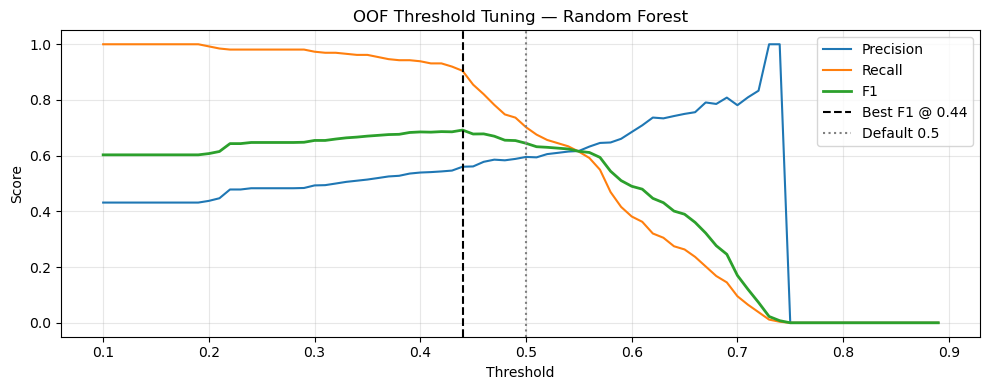

Best OOF threshold: 0.44  (F1=0.692)

Threshold=0.5:  P=0.608  R=0.727  F1=0.662

Threshold=0.44:  P=0.514  R=0.848  F1=0.640


In [13]:
# OOF predictions
oof_proba = np.zeros(len(y_train))
for tr_idx, val_idx in skf.split(X_tr_c[feats_final], y_train):
    X_f, X_v = X_tr_c[feats_final].iloc[tr_idx], X_tr_c[feats_final].iloc[val_idx]
    y_f      = y_train.iloc[tr_idx]
    m = build_rf(params_final)
    m.fit(X_f, y_f)
    oof_proba[val_idx] = m.predict_proba(X_v)[:, 1]

thresholds = np.arange(0.10, 0.90, 0.01)
rows = []
for t in thresholds:
    y_pred = (oof_proba >= t).astype(int)
    rows.append({
        'Threshold': round(t, 2),
        'Precision': precision_score(y_train, y_pred, zero_division=0),
        'Recall':    recall_score(y_train, y_pred, zero_division=0),
        'F1':        f1_score(y_train, y_pred, zero_division=0),
    })

df_thresh = pd.DataFrame(rows).set_index('Threshold')
best_t    = df_thresh['F1'].idxmax()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_thresh.index, df_thresh['Precision'], label='Precision')
ax.plot(df_thresh.index, df_thresh['Recall'],    label='Recall')
ax.plot(df_thresh.index, df_thresh['F1'],        label='F1', lw=2)
ax.axvline(best_t, color='black', linestyle='--', label=f'Best F1 @ {best_t}')
ax.axvline(0.5,    color='grey',  linestyle=':',  label='Default 0.5')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('OOF Threshold Tuning — Random Forest')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Best OOF threshold: {best_t}  (F1={df_thresh.loc[best_t, "F1"]:.3f})')

for t in [0.5, best_t]:
    y_pred = (y_proba_te >= t).astype(int)
    print(f'\nThreshold={t}:  '
          f'P={precision_score(y_test, y_pred):.3f}  '
          f'R={recall_score(y_test, y_pred):.3f}  '
          f'F1={f1_score(y_test, y_pred):.3f}')

## Diagnostics

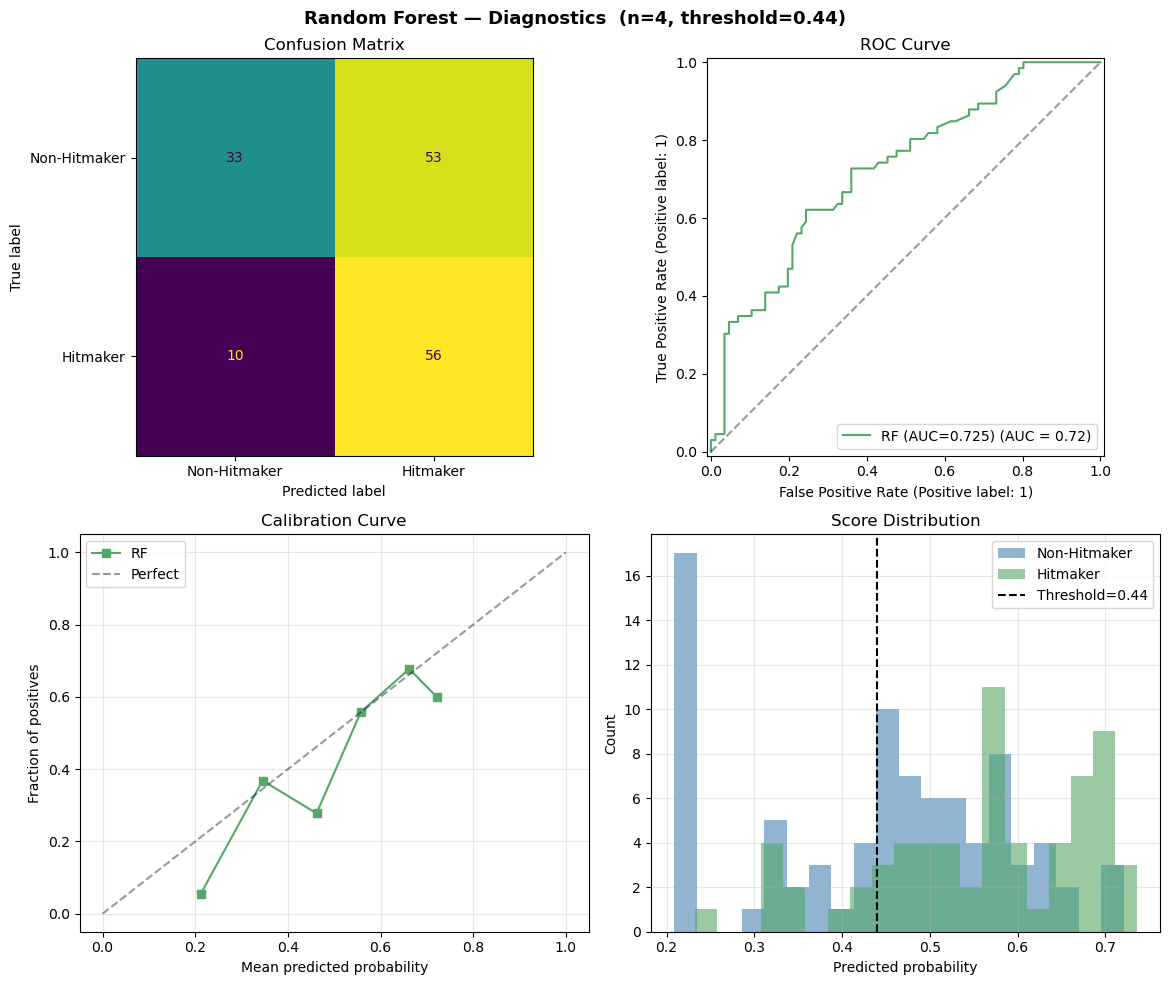

In [14]:
y_pred_final = (y_proba_te >= best_t).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f'Random Forest — Diagnostics  '
             f'(n={len(feats_final)}, threshold={best_t})',
             fontsize=13, fontweight='bold')

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final, ax=axes[0][0],
    display_labels=['Non-Hitmaker', 'Hitmaker'], colorbar=False
)
axes[0][0].set_title('Confusion Matrix')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba_te, ax=axes[0][1],
                                  name=f'RF (AUC={test_auc:.3f})', color='#55A868')
axes[0][1].plot([0,1],[0,1],'k--',alpha=0.4)
axes[0][1].set_title('ROC Curve')

# Calibration
prob_true, prob_pred = calibration_curve(y_test, y_proba_te, n_bins=10)
axes[1][0].plot(prob_pred, prob_true, 's-', color='#55A868', label='RF')
axes[1][0].plot([0,1],[0,1],'k--',alpha=0.4,label='Perfect')
axes[1][0].set_xlabel('Mean predicted probability')
axes[1][0].set_ylabel('Fraction of positives')
axes[1][0].set_title('Calibration Curve')
axes[1][0].legend(); axes[1][0].grid(True, alpha=0.3)

# Probability distribution
axes[1][1].hist(y_proba_te[y_test == 0], bins=20, alpha=0.6,
                color='steelblue', label='Non-Hitmaker')
axes[1][1].hist(y_proba_te[y_test == 1], bins=20, alpha=0.6,
                color='#55A868', label='Hitmaker')
axes[1][1].axvline(best_t, color='black', linestyle='--', label=f'Threshold={best_t}')
axes[1][1].set_xlabel('Predicted probability')
axes[1][1].set_ylabel('Count')
axes[1][1].set_title('Score Distribution')
axes[1][1].legend(); axes[1][1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## Feature Importance (SHAP)

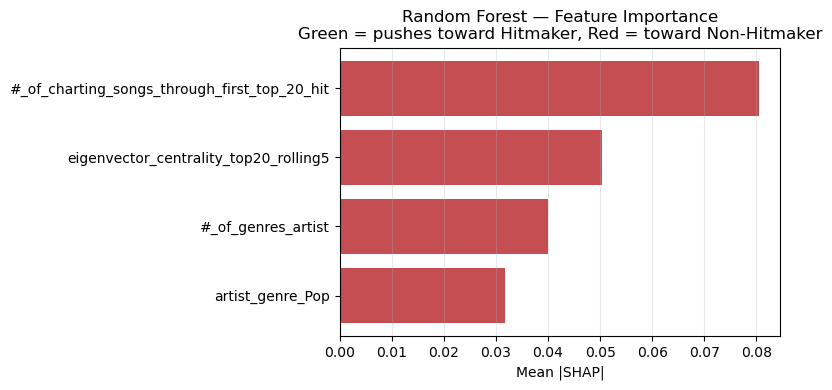


Summary:
  #_of_charting_songs_through_first_top_20_hit   SHAP=0.0805  → Non-Hitmaker
  eigenvector_centrality_top20_rolling5          SHAP=0.0503  → Non-Hitmaker
  #_of_genres_artist                             SHAP=0.0399  → Non-Hitmaker
  artist_genre_Pop                               SHAP=0.0318  → Non-Hitmaker


In [15]:
explainer = shap.TreeExplainer(model_final)
sv = explainer.shap_values(X_tr_c[feats_final])
if isinstance(sv, list): sv = sv[1]
elif sv.ndim == 3:        sv = sv[:, :, 1]

shap_abs    = pd.Series(np.abs(sv).mean(axis=0), index=feats_final).sort_values(ascending=False)
shap_signed = pd.Series(sv.mean(axis=0),          index=feats_final)
shap_signed = shap_signed.reindex(shap_abs.index)

colors = ['#55A868' if v >= 0 else '#C44E52' for v in shap_signed]

fig, ax = plt.subplots(figsize=(8, max(4, len(feats_final) * 0.45)))
ax.barh(shap_abs.index[::-1], shap_abs.values[::-1], color=colors[::-1])
ax.set_xlabel('Mean |SHAP|')
ax.set_title('Random Forest — Feature Importance\n'
             'Green = pushes toward Hitmaker, Red = toward Non-Hitmaker')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

print('\nSummary:')
for f in shap_abs.index:
    direction = '→ Hitmaker' if shap_signed[f] >= 0 else '→ Non-Hitmaker'
    print(f'  {f:<45}  SHAP={shap_abs[f]:.4f}  {direction}')

## Final Summary

In [16]:
y_pred_50  = (y_proba_te >= 0.50).astype(int)
y_pred_opt = (y_proba_te >= best_t).astype(int)

res_final = cv_results_by_n[winner_n]

print('=' * 60)
print(f'  Random Forest — Final Results (nb27)')
print('=' * 60)
print(f'  N features          : {len(feats_final)}')
print(f'  Features            : {feats_final}')
print(f'  Optuna λ            : {LAM}')
print()
print(f'  CV AUC    : {res_final["CV AUC"]:.4f} ± {res_final["CV Std"]:.4f}')
print(f'  Train AUC : {train_auc:.4f}')
print(f'  Test AUC  : {test_auc:.4f}')
print(f'  Gap       : {gap:.4f}')
print(f'  Logloss   : {log_loss(y_test, y_proba_te):.4f}')
print(f'  Brier     : {brier_score_loss(y_test, y_proba_te):.4f}')
print()
print(f'  Threshold=0.50  P={precision_score(y_test,y_pred_50):.3f}  '
      f'R={recall_score(y_test,y_pred_50):.3f}  F1={f1_score(y_test,y_pred_50):.3f}')
print(f'  Threshold={best_t}  P={precision_score(y_test,y_pred_opt):.3f}  '
      f'R={recall_score(y_test,y_pred_opt):.3f}  F1={f1_score(y_test,y_pred_opt):.3f}')
print()
print(f'  nb21 RF reference  →  Test AUC=0.7671  Gap=0.005  N=9')

  Random Forest — Final Results (nb27)
  N features          : 4
  Features            : ['#_of_charting_songs_through_first_top_20_hit', 'eigenvector_centrality_top20_rolling5', '#_of_genres_artist', 'artist_genre_Pop']
  Optuna λ            : 0.3

  CV AUC    : 0.7511 ± 0.0320
  Train AUC : 0.7720
  Test AUC  : 0.7248
  Gap       : 0.0472
  Logloss   : 0.6151
  Brier     : 0.2137

  Threshold=0.50  P=0.608  R=0.727  F1=0.662
  Threshold=0.44  P=0.514  R=0.848  F1=0.640

  nb21 RF reference  →  Test AUC=0.7671  Gap=0.005  N=9
